In [8]:
import yfinance as yf
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import time
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
#  DATA SETUP 
# ─────────────────────────────────────────────
STOCKS   = ["AAPL","MSFT","JPM","JNJ","XOM","AMZN","TSLA","GS","PFE","SPY"]
INIT_VAL = 100_000
N_SIMS   = 10_000
N_DAYS   = 252

print("Fetching data...")
all_data = {}
for ticker in STOCKS:
    try:
        df = yf.download(ticker, start="2019-01-01",
                         end="2024-01-01", auto_adjust=True, progress=False)
        all_data[ticker] = df
        time.sleep(0.5)
    except Exception as e:
        print(f"✗ {ticker}: {e}")

prices      = pd.DataFrame({t: d["Close"].squeeze() for t, d in all_data.items()}).dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()
weights     = np.array([1 / len(STOCKS)] * len(STOCKS))
port_returns= log_returns @ weights
mean_ret    = port_returns.mean()
std_ret     = port_returns.std()

# Monte Carlo
np.random.seed(42)
rand_rets  = np.random.normal(mean_ret, std_ret, (N_DAYS, N_SIMS))
port_paths = INIT_VAL * np.cumprod(1 + rand_rets, axis=0)
final_vals = port_paths[-1, :]
VaR_95     = INIT_VAL - np.percentile(final_vals, 5)

# Rolling volatility (needed for chart 4)
roll_vol   = log_returns.rolling(30).std() * np.sqrt(252)
port_vol   = port_returns.rolling(30).std() * np.sqrt(252)

# Normalised prices (needed for chart 5)
norm       = prices / prices.iloc[0] * 100

# Correlation (needed for chart 3)
corr       = log_returns.corr()

# Q-Q data (needed for chart 6)
(osm, osr), (slope, intercept, _) = stats.probplot(final_vals)

# Shared dark layout settings
DARK = dict(
    paper_bgcolor="#0d1117",
    plot_bgcolor="#0d1117",
    font=dict(color="#c9d1d9"),
    xaxis=dict(gridcolor="#21262d"),
    yaxis=dict(gridcolor="#21262d")
)

print("✓ All data ready — running charts...\n")

Fetching data...
✓ All data ready — running charts...



## Monte Carlo Paths

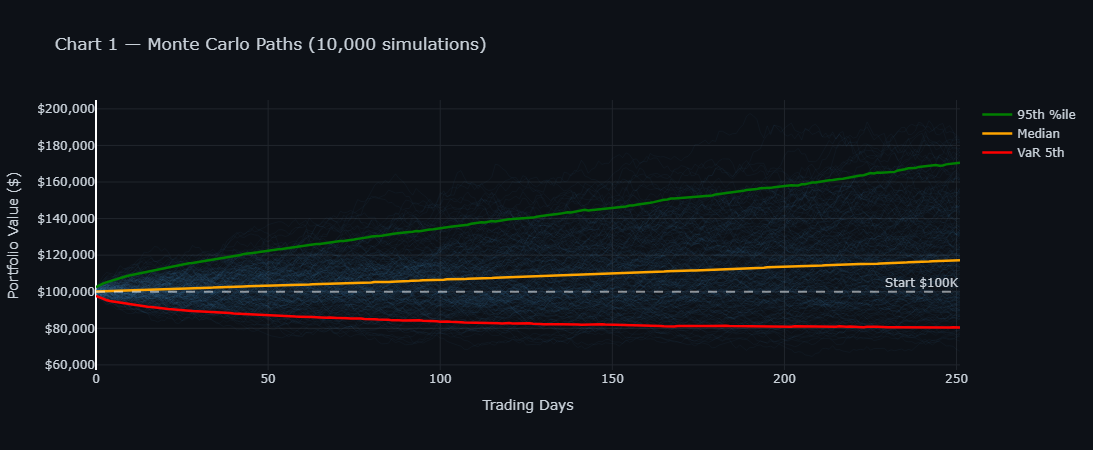

✓ Chart 1 shown


In [9]:
fig1 = go.Figure()

# 200 faint simulation paths
for i in range(0, 600, 3):
    fig1.add_trace(go.Scatter(
        y=port_paths[:, i], mode="lines",
        line=dict(color="steelblue", width=0.4),
        opacity=0.15, showlegend=False))

# Percentile lines
for pct, col, name in [(95,"green","95th %ile"),
                        (50,"orange","Median"),
                        (5, "red",  "VaR 5th")]:
    fig1.add_trace(go.Scatter(
        y=np.percentile(port_paths, pct, axis=1),
        mode="lines", name=name,
        line=dict(color=col, width=2.5)))

fig1.add_hline(y=INIT_VAL, line_dash="dash",
               line_color="white", opacity=0.5,
               annotation_text="Start $100K")

fig1.update_layout(
    **DARK,
    title="Chart 1 — Monte Carlo Paths (10,000 simulations)",
    height=450,
    xaxis_title="Trading Days",
    yaxis_title="Portfolio Value ($)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",")

fig1.show()
print("✓ Chart 1 shown")

## Final Value Distribution

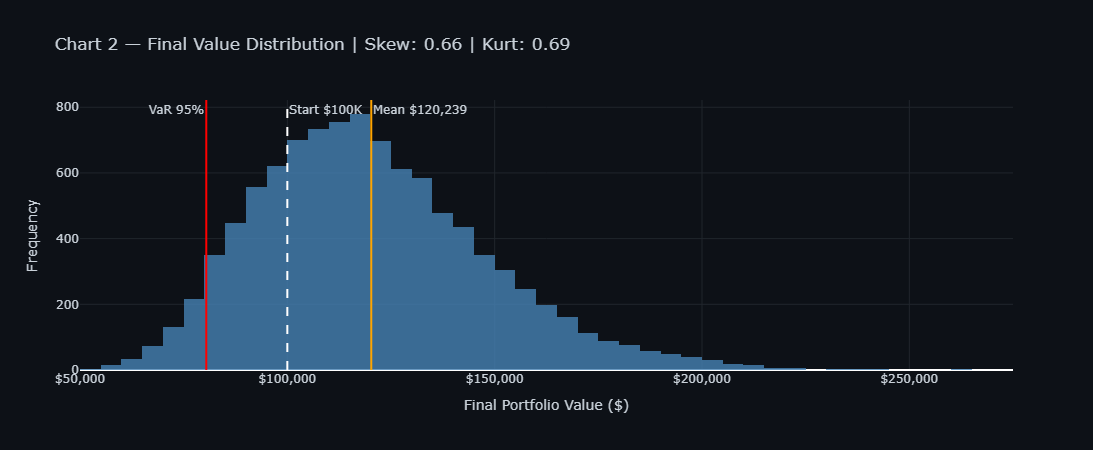

✓ Chart 2 shown


In [10]:
fig2 = go.Figure()

fig2.add_trace(go.Histogram(
    x=final_vals, nbinsx=80,
    marker_color="steelblue", opacity=0.8,
    name="Simulations"))

fig2.add_vline(x=INIT_VAL,
               line_dash="dash", line_color="white",
               annotation_text="Start $100K",
               annotation_position="top right")

fig2.add_vline(x=np.percentile(final_vals, 5),
               line_color="red", line_width=2,
               annotation_text="VaR 95%",
               annotation_position="top left")

fig2.add_vline(x=np.mean(final_vals),
               line_color="orange", line_width=2,
               annotation_text=f"Mean ${np.mean(final_vals):,.0f}",
               annotation_position="top right")

fig2.update_layout(
    **DARK,
    title=f"Chart 2 — Final Value Distribution | "
          f"Skew: {stats.skew(final_vals):.2f} | "
          f"Kurt: {stats.kurtosis(final_vals):.2f}",
    height=450,
    xaxis_title="Final Portfolio Value ($)",
    yaxis_title="Frequency",
    xaxis_tickprefix="$",
    xaxis_tickformat=",")

fig2.show()
print("✓ Chart 2 shown")

##  Correlation Heatmap

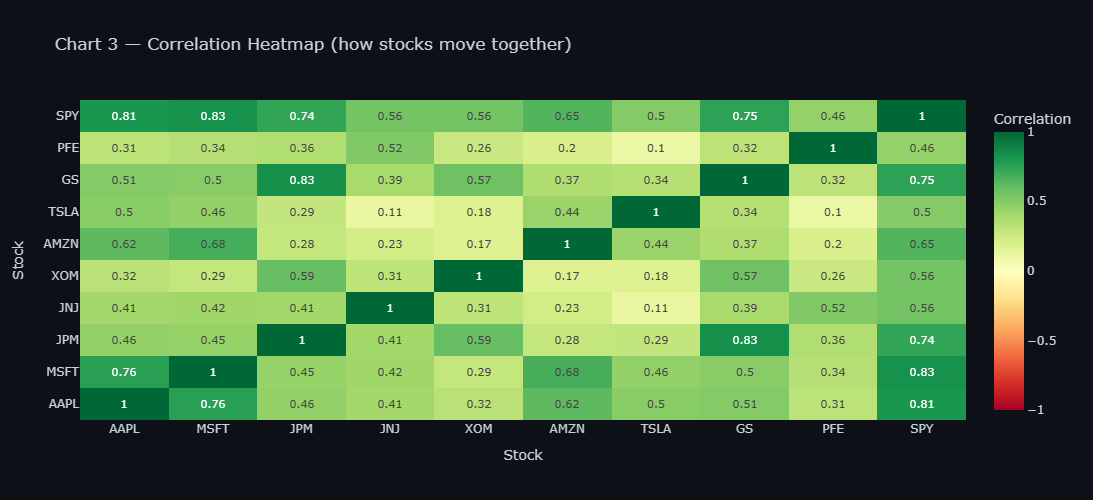

✓ Chart 3 shown


In [11]:
fig3 = go.Figure(go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.index,
    colorscale="RdYlGn",
    zmid=0,
    text=np.round(corr.values, 2),
    texttemplate="%{text}",
    textfont=dict(size=11),
    colorbar=dict(title="Correlation")))

fig3.update_layout(
    **DARK,
    title="Chart 3 — Correlation Heatmap (how stocks move together)",
    height=500,
    xaxis_title="Stock",
    yaxis_title="Stock")

fig3.show()
print("✓ Chart 3 shown")

## Rolling 30-Day Volatility

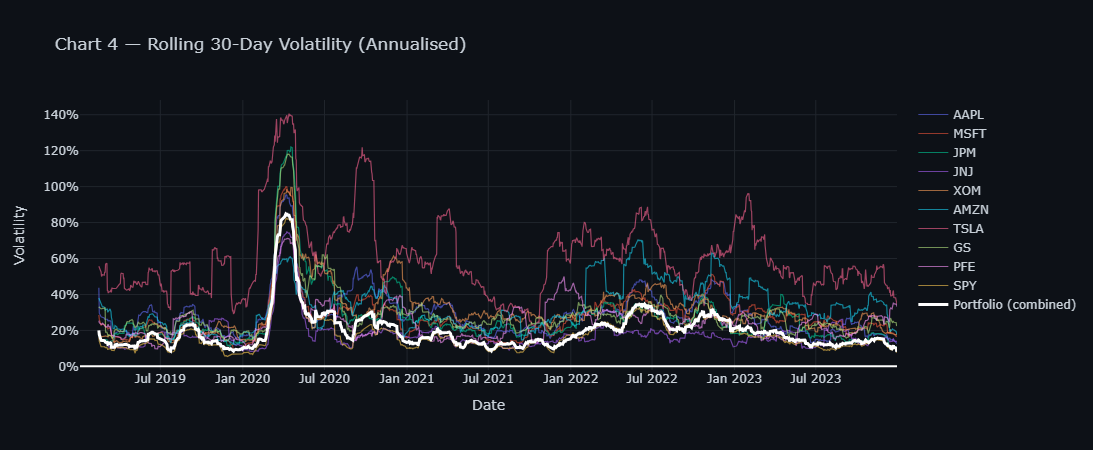

✓ Chart 4 shown


In [13]:
fig4 = go.Figure()

# Individual stocks (faint)
for col in roll_vol.columns:
    fig4.add_trace(go.Scatter(
        x=roll_vol.index, y=roll_vol[col],
        mode="lines", name=col,
        line=dict(width=1.2), opacity=0.6))

# Portfolio line (bold white)
fig4.add_trace(go.Scatter(
    x=port_vol.index, y=port_vol,
    mode="lines", name="Portfolio (combined)",
    line=dict(color="white", width=3)))

fig4.update_layout(
    **DARK,
    title="Chart 4 — Rolling 30-Day Volatility (Annualised)",
    height=450,
    xaxis_title="Date",
    yaxis_title="Volatility",
    yaxis_tickformat=".0%")

fig4.show()
print("✓ Chart 4 shown")